In [1]:
from __future__ import unicode_literals, print_function, division
import unicodedata
import re

SOS_token = 0
EOS_token = 1

class Lang:
# 定义一个Lang类（Language），用于管理词汇表、词汇到索引的映射、以及词频计数。
    def __init__(self, name):
        self.name = name
        # 存储语言名称（如 'eng' 或 'fra'）。
        self.word2index = {}
        # 字典：存储词语到其整数索引的映射（用于模型输入）。
        self.word2count = {}
        # 字典：存储每个词语出现的次数（用于词频统计和可选的过滤）。
        self.index2word = {0: "SOS", 1: "EOS"}
        # 字典：存储整数索引到词语的映射。初始化时已包含SOS和EOS标记。
        self.n_words = 2  # Count SOS and EOS
        # 词汇表中的词语总数。从2开始计数（已包含SOS和EOS）。

    def addSentence(self, sentence):
    # 方法：将句子中的所有词语添加到词汇表中。
        for word in sentence.split(' '):
        # 按空格分割句子，迭代每个词语。
            self.addWord(word)
            # 调用addWord方法处理单个词语。

    def addWord(self, word):
    # 方法：处理单个词语，更新词汇表和计数。
        if word not in self.word2index:
        # 如果词语是新的，尚未在词汇表中。
            self.word2index[word] = self.n_words
            # 为新词分配当前的n_words作为索引。
            self.word2count[word] = 1
            # 初始化该词的计数为1。
            self.index2word[self.n_words] = word
            # 将新索引和词语添加到index2word映射中。
            self.n_words += 1
            # 词汇表大小加1。
        else:
        # 如果词语已经存在。
            self.word2count[word] += 1
            # 仅增加该词的计数。

# Turn a Unicode string to plain ASCII, thanks to
def unicodeToAscii(s):
    # 函数：将Unicode字符串转换为纯ASCII字符串。
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        # 第一步：使用 'NFD'（Normalization Form Decomposition）进行规范化。
        # 它将字符分解为基字符和组合标记（例如，'é'分解为'e'和重音符）。
        if unicodedata.category(c) != 'Mn'
        # 第二步：过滤掉类别为 'Mn' (Mark, Nonspacing) 的字符。
        # 也就是移除非间距标记（如重音、音调符号等），实现“去重音”效果。
    )
# ---

# Lowercase, trim, and remove non-letter characters
def normalizeString(s):
    # 函数：对单个字符串进行标准化处理（清理文本）。
    s = unicodeToAscii(s.lower().strip())
    # 步骤1：转换为ASCII，转换为小写，并去除首尾空白。
    s = re.sub(r"([.!?])", r" \1", s)
    # 步骤2：使用正则表达式在标点符号 (.!?) 前面添加一个空格。
    # 这样，在后续的split(' ')操作中，标点符号会被视作独立的“词语”。
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    # 步骤3：移除所有非字母、非标点符号的字符，替换为单个空格。
    # 清理掉数字、括号、特殊符号等。
    return s

def readLangs(lang1, lang2, reverse=False):
    # 函数：读取语言数据文件，并进行初步处理。
    print("Reading lines...")
    # Read the file and split into lines
    lines = open('data/%s-%s.txt' % (lang1, lang2), encoding='utf-8').\
        read().strip().split('\n')
    # 步骤1：打开并读取数据文件
    # 以 UTF-8 编码读取，去除首尾空白，然后按换行符分割成列表。
    # Split every line into pairs and normalize
    pairs = [[normalizeString(s) for s in l.split('\t')[:2]] for l in lines]
    # 步骤2：遍历每一行（每一对句子）。
    # l.split('\t')[:2]：按制表符（\t）分割，只取前两列（输入和输出句子）。
    # 对每对句子中的两个字符串都调用 normalizeString 进行清洗。
    # Reverse pairs, make Lang instances #正反互换翻译
    if reverse:
        # 如果设置了 reverse=True，则交换句子对的顺序（用于反向翻译，例如从法语翻译到英语）。
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        # 此时，输入语言是第二个语言（lang2）。
        output_lang = Lang(lang1)
        # 输出语言是第一个语言（lang1）。
    else:
        # 默认顺序：lang1 -> lang2。
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)
    return input_lang, output_lang, pairs
    # 返回初始化后的Lang对象和清洗后的句子对列表。


def filterPair(p,MAX_LENGTH,eng_prefixes):
    # 函数：检查单个句子对是否满足筛选条件。
    return len(p[0].split(' ')) < MAX_LENGTH and len(p[1].split(' ')) < MAX_LENGTH and  p[1].startswith(eng_prefixes)
        # 条件1：输入句子（p[0]）的词数小于最大长度限制。
        # 条件2：输出句子（p[1]）的词数小于最大长度限制。
        # 条件3：输出句子（这里通常是英语）以预定义的常用短语开头（例如：'I am ', 'You are '）。
        # 这是为了减少训练集大小和复杂度，只专注于简单的句子。

def filterPairs(pairs,MAX_LENGTH,eng_prefixes):
    # 函数：应用 filterPair 对所有句子对进行批量筛选。
    return [pair for pair in pairs if filterPair(pair,MAX_LENGTH,eng_prefixes)]
    # 使用列表推导式，只保留满足 filterPair 条件的句子对。

def prepareData(lang1, lang2, MAX_LENGTH ,eng_prefixes, reverse=False):
    # 核心函数：协调所有预处理步骤，准备最终的训练数据。
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    # 步骤1：读取文件，进行基本清理，并根据 reverse 确定输入/输出语言。
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs,MAX_LENGTH,eng_prefixes)
    # 步骤2：根据最大长度和前缀条件筛选句子对。
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
    # 步骤3：遍历所有筛选后的句子对，构建词汇表（计数词语）。
        input_lang.addSentence(pair[0])
        # 将输入句子中的所有词添加到 input_lang 的词汇表中。
        output_lang.addSentence(pair[1])
        # 将输出句子中的所有词添加到 output_lang 的词汇表中。
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    # 打印输入语言的名称和词汇表大小。
    print(output_lang.name, output_lang.n_words)
    # 打印输出语言的名称和词汇表大小。

    return input_lang, output_lang, pairs
    # 返回最终的输入语言 Lang 对象、输出语言 Lang 对象和筛选后的句子对。

def indexesFromSentence(lang, sentence):
    # 函数：将句子（字符串）转换为对应的词汇索引列表（Python list of integers）。
    return [lang.word2index[word] for word in sentence.split(' ')]
    # 使用列表推导式：
    # 1. sentence.split(' ')：按空格将句子拆分成词语列表。
    # 2. lang.word2index[word]：查找 Lang 实例中每个词语对应的整数索引。

def tensorFromSentence(lang, sentence):
    # 函数：将句子转换为 PyTorch 张量（Tensor），并添加 EOS 标记。
    indexes = indexesFromSentence(lang, sentence)
    # 步骤1：将句子转换为词汇索引列表。
    indexes.append(EOS_token)
    # 步骤2：在序列末尾添加“序列结束” (EOS) 标记的索引（值为 1）。
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)
    # 步骤3：将索引列表转换为 PyTorch 张量。
    # - dtype=torch.long：确保数据类型为长整型，这是索引和序列输入的标准类型。
    # - device=device：将张量移动到先前定义的设备（CPU 或 GPU）。
    # - .view(-1, 1)：重塑张量。Seq2Seq 模型通常要求输入是 (序列长度, 1) 的形状，
    #   其中 1 代表批次大小（这里是 1，因为每次只处理一个句子）。

def tensorsFromPair(pair):
    # 函数：将一个句子对（[输入句子, 目标句子]）转换为输入和目标张量对。
    # 注意：这个函数依赖于全局变量 input_lang 和 output_lang。
    input_tensor = tensorFromSentence(input_lang, pair[0])
    # 步骤1：将句子对的第一个元素（输入句子）转换为张量。
    target_tensor = tensorFromSentence(output_lang, pair[1])
    # 步骤2：将句子对的第二个元素（目标句子）转换为张量。
    return (input_tensor, target_tensor)
    # 返回包含输入张量和目标张量的元组，可直接用于模型训练。


In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
from sklearn.model_selection import train_test_split
#generate the train test set

MAX_LENGTH = 15
eng_prefixes = (
    "i am", "i m",
    "he is", "he s",
    "she is", "she s",
    "you are", "you re",
    "we are", "we re",
    "they are", "they re"
)
#data prepare
input_lang, output_lang, pairs = prepareData('eng', 'fra', MAX_LENGTH,eng_prefixes, True)
X = [i[0] for i in pairs]
y = [i[1] for i in pairs]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
train_pairs = list(zip(X_train,y_train))
test_pairs = list(zip(X_test,y_test))
#print an example
print(train_pairs[0])
print(test_pairs[0])

Reading lines...
Read 239189 sentence pairs
Trimmed to 23543 sentence pairs
Counting words...
Counted words:
fra 7142
eng 4737
('nous n en avons pas termine .', 'we re not done .')
('il aurait du travailler plus .', 'he should have worked harder .')


In [8]:
import time
import math
from torch import optim
import random
from torchmetrics.text.rouge import ROUGEScore
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle

def train(teacher_forcing_ratio, input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, max_length=MAX_LENGTH, encoder_fetch_wholeseq=False, if_attention=False,use_transformer_encoder=False):
    encoder_optimizer.zero_grad() # 清除编码器梯度
    decoder_optimizer.zero_grad() # 清除解码器梯度
    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)
    loss = 0
    encoder_hidden = encoder.initHidden() # 初始化编码器的隐藏状态（对于 LSTM/Bi-LSTM 是 (h0, c0) 元组）
    # --- 1. Encoder 编码部分 ---

    #input_tensor (L,1)
    if encoder_fetch_wholeseq == True:
        # 双向/序列 Encoder 模式：将整个序列一次性输入 Encoder
        # print(input_tensor.size())
        # 输入tensor (L,1)
        encoder_outputs, encoder_hidden = encoder(input_tensor) # 编码整个序列
        decoder_hidden = encoder_hidden # Decoder 初始 hidden 使用 Encoder 最终 hidden

    if encoder_fetch_wholeseq == False:
        # 单向/单步 RNN Encoder 模式：逐个字符输入 Encoder
        encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)
        for ei in range(input_length):
            # 逐个字符作为 tensor 输入
            # 注意：此处的 encoder 必须支持单步输入 (input_tensor[ei], encoder_hidden)
            #print(input_tensor[ei].size()) 形状为 [1]
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs[ei] = encoder_output[0, 0] # 记录每个时间步的输出
        decoder_hidden = encoder_hidden # Decoder 初始 hidden 使用 Encoder 最终 hidden

    decoder_input = torch.tensor([[SOS_token]], device=device) # 解码器初始输入是 SOS 标记
    # 确保 encoder_outputs 维度正确，以便 Attention 使用 (Max_Length, Batch_Size, Hidden_Size)

    use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False # 随机决定是否使用 Teacher Forcing

    if use_teacher_forcing:
        # 使用 Teacher forcing (将实际目标作为下一步输入)
        for di in range(target_length):
            if if_attention:
                # 使用 Attention 的解码器 (输入: input, hidden, encoder_outputs)
                decoder_output, decoder_hidden, decoder_attention = decoder(
                    decoder_input, decoder_hidden, encoder_outputs)
            else:
                # 不使用 Attention 的解码器 (输入: input, hidden)
                decoder_output, decoder_hidden = decoder(
                    decoder_input, decoder_hidden)

            loss += criterion(decoder_output, target_tensor[di]) # 计算损失
            decoder_input = target_tensor[di]  # Teacher forcing: 使用实际目标作为下一个输入

    else:
        # 不使用 Teacher forcing (将预测结果作为下一步输入)
        for di in range(target_length):
            if if_attention:
                # 使用 Attention 的解码器
                decoder_output, decoder_hidden, decoder_attention = decoder(
                    decoder_input, decoder_hidden, encoder_outputs)
            else:
                # 不使用 Attention 的解码器
                decoder_output, decoder_hidden = decoder(
                    decoder_input, decoder_hidden)

            topv, topi = decoder_output.topk(1) # 获取预测概率最高的词汇索引
            decoder_input = topi.squeeze().detach()  # 将预测结果作为下一个输入，并从计算图中分离

            loss += criterion(decoder_output, target_tensor[di]) # 计算损失
            if decoder_input.item() == EOS_token:
                break # 遇到 EOS 标记则停止解码

    loss.backward() # 反向传播计算梯度
    encoder_optimizer.step() # 更新编码器参数
    decoder_optimizer.step() # 更新解码器参数
    return loss.item() / target_length # 返回平均损失


def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

def trainIters(teacher_forcing_ratio, encoder, decoder, epochs, print_every=1000, plot_loss_path=None, learning_rate=0.01, save_checkpoints_path=None,encoder_fetch_wholeseq=False,if_attention=False,use_transformer_encoder=False):
    start = time.time() # 记录训练开始时间
    plot_losses = []    # 存储所有迭代的损失值，用于绘图
    print_loss_total = 0  # 累加损失，每 print_every 步重置
    plot_loss_total = 0   # 累加损失，（在原始代码中未区分 plot_loss_total，但保留其定义）

    # 初始化优化器
    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)

    criterion = nn.NLLLoss() # 使用负对数似然损失函数

    iter = 1 # 迭代计数器
    n_iters = len(train_pairs) * epochs # 计算总训练迭代次数

    for epoch in range(epochs): # 循环每个 epoch
        print("Epoch: %d/%d" % (epoch, epochs))
        for training_pair in train_pairs: # 循环每个训练样本
            training_pair = tensorsFromPair(training_pair) # 将 (input, target) 转换为 tensor

            input_tensor = training_pair[0]
            target_tensor = training_pair[1]
            # 执行单次训练迭代
            loss = train(teacher_forcing_ratio, input_tensor, target_tensor, encoder,
                        decoder, encoder_optimizer, decoder_optimizer, criterion, encoder_fetch_wholeseq=encoder_fetch_wholeseq,
                         if_attention=if_attention,use_transformer_encoder=use_transformer_encoder)

            print_loss_total += loss # 累加打印损失
            plot_loss_total += loss  # 累加绘图损失
            plot_losses.append(loss) # 记录当前迭代的损失

            if iter % print_every == 0:
                print_loss_avg = print_loss_total / print_every # 计算平均损失
                print_loss_total = 0                           # 重置累加损失
                # 打印时间、迭代次数、完成百分比和平均损失
                print('%s (%d %d%%) %.4f' % (timeSince(start, iter / n_iters),iter, iter / n_iters * 100, print_loss_avg))
            iter +=1

        if save_checkpoints_path!=None:
            save_path=save_checkpoints_path+'/'+'checkpoint_epoch_'+str(epoch)+'.pth'
            save_checkpoint(epoch, encoder, decoder, encoder_optimizer, decoder_optimizer, print_loss_avg, save_path) # 保存检查点

    if plot_loss_path != None: # 如果指定了绘图路径
        np.random.seed(42) # 设置随机种子以保证结果可复现
        raw_loss_list = plot_losses

        loss_series = pd.Series(raw_loss_list)
        WINDOW_SIZE = 20 # 设置平滑窗口大小
        smoothed_loss = loss_series.rolling(window=WINDOW_SIZE, min_periods=1).mean() # 计算滚动平均（平滑损失）

        DESIRED_POINTS = 1000 # 期望在图上绘制的点数

        total_steps = len(raw_loss_list)
        if total_steps > DESIRED_POINTS:
            # 如果点数过多，则进行采样
            # sample_step = total_steps // DESIRED_POINTS
            sample_indices = np.linspace(0, total_steps - 1, DESIRED_POINTS, dtype=int) # 均匀采样索引
        else:
             # 否则，绘制所有点
            sample_indices = np.arange(total_steps)
            sample_step = 1

        sampled_steps = sample_indices
        sampled_raw_loss = [raw_loss_list[i] for i in sample_indices]
        sampled_smoothed_loss = [smoothed_loss[i] for i in sample_indices]

        plt.figure(figsize=(12, 6))
        if total_steps > DESIRED_POINTS: # 只有当采样发生时才绘制采样点
            plt.plot(sampled_steps, sampled_raw_loss,
                     label='Raw Loss (Sampled)',
                     color='lightgray',
                     linestyle='--',
                     alpha=0.6,
                     marker='.',
                     markersize=4)


        plt.plot(sampled_steps, sampled_smoothed_loss,
                label=f'Smoothed Loss (Window={WINDOW_SIZE}, {len(sampled_steps)} points)',
                 color='red',
                linewidth=2)

        plt.title('Training Loss Curve (Sampled Points)', fontsize=16)
        plt.xlabel('Training Steps', fontsize=14)
        plt.ylabel('Loss Value', fontsize=14)
        plt.legend()
        plt.grid(True)
        #plt.show()
        plt.savefig(plot_loss_path+'/training_loss_curve.png') # 保存损失曲线图
        #保存所有最终loss值
        with open(plot_loss_path+'/training_loss_curve.pkl', 'wb') as f:
            pickle.dump(plot_losses, f) # 保存原始损失数据


def evaluate(encoder, decoder, sentence, max_length=MAX_LENGTH, encoder_fetch_wholeseq=False,if_attention=False):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)
        input_length = input_tensor.size()[0]
        encoder_hidden = encoder.initHidden()

        #print("encoder_fetch_wholeseq",encoder_fetch_wholeseq)

        if encoder_fetch_wholeseq==False:
            encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)
            for ei in range(input_length):
                encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
                encoder_outputs[ei] = encoder_output[0, 0]

            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden

        #双向序列，把整个 input_tensor 直接输入 encoder
        if encoder_fetch_wholeseq==True:
            encoder_outputs, encoder_hidden = encoder(input_tensor)
            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden


        decoded_words = []
        for di in range(max_length):
            if if_attention:
                # 使用 Attention 的解码器
                decoder_output, decoder_hidden, decoder_attention = decoder(
                    decoder_input, decoder_hidden, encoder_outputs)
            else:
                # 不使用 Attention 的解码器（原代码逻辑）
                decoder_output, decoder_hidden = decoder(
                    decoder_input, decoder_hidden)
            topv, topi = decoder_output.data.topk(1)
            if topi.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            else:
                decoded_words.append(output_lang.index2word[topi.item()])
            decoder_input = topi.squeeze().detach()

        return decoded_words

def evaluateRandomly(encoder, decoder, n=10, encoder_fetch_wholeseq=False,if_attention=False):
    for i in range(n):
        pair = random.choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words = evaluate(encoder, decoder, pair[0], encoder_fetch_wholeseq=encoder_fetch_wholeseq,if_attention=if_attention)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

def inference(encoder, decoder, testing_pairs, encoder_fetch_wholeseq=False,if_attention=False):
    input = []
    gt = []
    predict = []
    from tqdm import tqdm
    for i in tqdm(range(len(testing_pairs))):
        pair = testing_pairs[i]
        output_words = evaluate(encoder, decoder, pair[0], encoder_fetch_wholeseq=encoder_fetch_wholeseq,if_attention=if_attention)
        output_sentence = ' '.join(output_words)
        input.append(pair[0])
        gt.append(pair[1])
        predict.append(output_sentence)

    return input,gt,predict

def save_checkpoint(epoch, encoder, decoder, encoder_optimizer, decoder_optimizer, loss, filepath):
    """保存模型的检查点（checkpoint）"""
    torch.save({
        'epoch': epoch,
        'encoder_state_dict': encoder.state_dict(),
        'decoder_state_dict': decoder.state_dict(),
        'encoder_optimizer_state_dict': encoder_optimizer.state_dict(),
        'decoder_optimizer_state_dict': decoder_optimizer.state_dict(),
        'loss': loss,
    }, filepath)

def eval(gt, predict):
  rouge = ROUGEScore()
  metric_score = rouge(predict, gt)
  print("=== Evaluation score - Rouge score ===")
  print("Rouge1 fmeasure:\t",metric_score["rouge1_fmeasure"].item())
  print("Rouge1 precision:\t",metric_score["rouge1_precision"].item())
  print("Rouge1 recall:  \t",metric_score["rouge1_recall"].item())
  print("Rouge2 fmeasure:\t",metric_score["rouge2_fmeasure"].item())
  print("Rouge2 precision:\t",metric_score["rouge2_precision"].item())
  print("Rouge2 recall:  \t",metric_score["rouge2_recall"].item())
  print("=====================================")

In [2]:
import torch.nn as nn
import torch.nn.functional as F

class EncoderRNN(nn.Module):
    # 定义编码器类，继承自 nn.Module
    def __init__(self, input_size, hidden_size):
        # 构造函数：input_size 是输入词汇表大小，hidden_size 是隐藏层维度
        super(EncoderRNN, self).__init__()
        # 调用父类构造函数
        self.hidden_size = hidden_size
        # 存储隐藏层大小
        self.embedding = nn.Embedding(input_size, hidden_size)
        # 嵌入层：将输入词元（索引）映射到稠密的 hidden_size 维向量
        self.gru = nn.GRU(hidden_size, hidden_size)
        # GRU层：核心循环单元，输入和输出维度都是 hidden_size
    def forward(self, input, hidden):
        # 前向传播函数：处理单个输入词元
        # input: 当前时间步的输入词元（索引），形状通常为 (1)
        # hidden: 上一时间步的隐藏状态，形状 (1, 1, hidden_size)
        embedded = self.embedding(input).view(1, 1, -1)
        # 1. 嵌入：查找嵌入向量
        # 2. 塑形：将嵌入向量从 (1, hidden_size) [embedding 的输出] 塑形为 GRU 期望的 (seq_len=1, batch_size=1, hidden_size)
        output = embedded
        # 初始 GRU 输入为嵌入向量
        output, hidden = self.gru(output, hidden)
        # 通过 GRU 单元：计算新的输出和新的隐藏状态
        # output: 当前时间步的输出 (通常被忽略)
        # hidden: GRU 的最终隐藏状态 (包含上下文信息)
        return output, hidden
        # 返回 GRU 输出和更新后的隐藏状态（上下文向量）
    def initHidden(self):
        # 初始化隐藏状态函数
        return torch.zeros(1, 1, self.hidden_size, device=device)
        # 返回一个全零张量作为初始隐藏状态，形状 (num_layers=1, batch_size=1, hidden_size)

class Decoder(nn.Module):
    # 定义解码器类
    def __init__(self, hidden_size, output_size):
        # 构造函数：hidden_size 是隐藏层维度，output_size 是输出词汇表大小
        super(Decoder, self).__init__()
        # 调用父类构造函数
        self.hidden_size = hidden_size
        # 存储隐藏层大小
        self.embedding = nn.Embedding(output_size, hidden_size)
        # 嵌入层：将目标词元（索引）映射到 hidden_size 维向量
        self.gru = nn.GRU(hidden_size, hidden_size)
        # GRU层：核心循环单元，输入和输出维度都是 hidden_size
        self.out = nn.Linear(hidden_size, output_size)
        # 线性层：将 GRU 的隐藏状态映射到输出词汇表的维度
        self.softmax = nn.LogSoftmax(dim=1)
        # LogSoftmax：将线性层的输出转换为对数概率（Log-probabilities），通常用于计算损失。

    def forward(self, input, hidden):
        # 前向传播函数：解码器的一个时间步
        # input: 当前时间步的输入词元（通常是上一步的预测结果或教师强制的真实标签）
        # hidden: 当前时间步的隐藏状态（初始时为编码器的上下文向量）

        output = self.embedding(input).view(1, 1, -1)
        # 1. 嵌入：查找输入词元的嵌入向量
        # 2. 塑形：从 (1, hidden_size) 塑形为 (seq_len=1, batch_size=1, hidden_size)
        output = F.relu(output)
        # 应用 ReLU 激活函数（在 GRU 之前使用是可选的设计）
        output, hidden = self.gru(output, hidden)
        # 通过 GRU 单元：处理当前输入词元和隐藏状态，得到新的输出和隐藏状态
        # --- 下面是关键的输出处理部分 ---
        output_for_linear = output.squeeze(0) # 修正或优化点：从 (1, 1, H) 变为 (1, H)
        # 为了清晰和健壮，推荐使用 .squeeze(0) 来移除序列长度为 1 的维度。
        output = self.softmax(self.out(output_for_linear))
        # 1. self.out(...)：将 (1, hidden_size) 映射到 (1, output_size)
        # 2. self.softmax(...)：应用 LogSoftmax，得到预测词元的对数概率
        return output, hidden
        # 返回预测的词元概率对数和更新后的隐藏状态

    def initHidden(self):
        # 初始化隐藏状态函数
        return torch.zeros(1, 1, self.hidden_size, device=device)
        # 返回一个全零张量作为初始隐藏状态（通常在 Seq2Seq 中不使用，而是接收编码器的输出）


In [ ]:
#begin training
#TASK.1 GRU
hidden_size = 256
teacher_forcing_ratio=0.5
epochs = 5
save_checkpoints_path='./checkpoints/task1'
plot_loss_path='./checkpoints/task1'

#to conotinue from interrupted process 注释以下两行来阻止编码器和解码器初始化
encoder1 = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder1 = Decoder(hidden_size, output_lang.n_words).to(device)
trainIters(teacher_forcing_ratio=teacher_forcing_ratio, encoder=encoder1, decoder=decoder1,
           epochs=epochs, print_every=5000, plot_loss_path=plot_loss_path, learning_rate=0.01,save_checkpoints_path=save_checkpoints_path)


In [ ]:
evaluateRandomly(encoder1, decoder1)
input,gt,predict = inference(encoder1, decoder1, test_pairs)
eval(gt, predict)

In [75]:
with open('./checkpoints/task1/training_loss_curve.pkl', 'rb') as f:
    # 使用 load() 从文件读取列表
    loaded_list = pickle.load(f)
print(len(loaded_list))


21188


In [81]:
#load from check point
hidden_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = './checkpoints/task1/checkpoint_epoch_4.pth'

encoder1 = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder1 = Decoder(hidden_size, output_lang.n_words).to(device)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
encoder1.load_state_dict(checkpoint['encoder_state_dict'])
decoder1.load_state_dict(checkpoint['decoder_state_dict'])

evaluateRandomly(encoder1, decoder1)
input,gt,predict = inference(encoder1, decoder1, test_pairs)
eval(gt, predict)

> ce que vous pensez ne m interesse guere .
= i m not interested in what you think .
< i m not interested in you what i m . <EOS>

> nous sommes du meme tonneau .
= we are two of a kind .
< we re a of of . . . . <EOS>

> je suis sur de ma decision a .
= i m sure of my decision .
< i m sure of my decision . <EOS>

> j ai chaud dans ce manteau .
= i m hot in this coat .
< i m on the wrong this . <EOS>

> j ai bien peur de vous devoir des excuses .
= i m afraid that i owe you an apology .
< i m afraid that i you . <EOS>

> je vais tenter ma chance .
= i m going to take my chances .
< i m going to take my my . <EOS>

> nous nous battons encore .
= we re still fighting .
< we re still shopping . <EOS>

> je ne vais pas t attaquer en justice .
= i m not going to sue you .
< i m not going to you you . <EOS>

> nous n en sommes pas si surs .
= we re not so sure .
< we re not so sure . <EOS>

> il est le garcon le plus apprecie de la classe .
= he s the most popular boy in the class .
< he s th

100%|██████████| 2355/2355 [00:11<00:00, 205.04it/s]


=== Evaluation score - Rouge score ===
Rouge1 fmeasure:	 0.620948851108551
Rouge1 precision:	 0.5874614119529724
Rouge1 recall:  	 0.6673239469528198
Rouge2 fmeasure:	 0.4391239881515503
Rouge2 precision:	 0.4075421690940857
Rouge2 recall:  	 0.48498106002807617


In [49]:
class Encoder_LSTM(nn.Module):
    # 定义编码器类，继承自 nn.Module
    def __init__(self, input_size, hidden_size):
        # 构造函数：input_size 是输入词汇表大小，hidden_size 是隐藏层维度
        super(Encoder_LSTM, self).__init__()
        # 调用父类构造函数
        self.hidden_size = hidden_size
        # 存储隐藏层大小
        self.embedding = nn.Embedding(input_size, hidden_size)
        # 嵌入层：将输入词元（索引）映射到稠密的 hidden_size 维向量
        self.lstm = nn.LSTM(hidden_size, hidden_size)
        # LSTM层：核心循环单元，输入和输出维度都是 hidden_size

    def forward(self, input, hidden_and_cell):
        # 前向传播函数：处理单个输入词元
        # input: 当前时间步的输入词元（索引），形状为 (1)
        # hidden: 上一时间步的隐藏状态，形状 (1, 1, hidden_size)
        #(seq_lenth, batch, hidden_size) --> (1,1,hidden_size)
        embedded = self.embedding(input).view(1, 1, -1)
        # 1. 嵌入：查找嵌入向量
        # 2. 塑形：将嵌入向量从 (1, hidden_size) [embedding 的输出] 塑形为 GRU 期望的 (seq_len=1, batch_size=1, hidden_size)
        output = embedded
        # 初始 LSTM 输入为嵌入向量
        output, hidden_and_cell = self.lstm(output, hidden_and_cell)
        # 通过 LSTM 单元：计算新的输出和新的隐藏状态
        # output: 当前时间步的输出 (通常被忽略)
        # LSTM 的 hidden 是一个元组 (h_new, c_new)
        # hidden_and_cell: lstm 的最终参数 (output, (h_new, c_new))
        return output, hidden_and_cell
        # 返回 GRU 输出和更新后的隐藏状态（上下文向量）
    def initHidden(self):
        # 初始化隐藏状态函数
        h0 = torch.zeros(1, 1, self.hidden_size, device=device)
        c0 = torch.zeros(1, 1, self.hidden_size, device=device)
        return (h0, c0)
        # 返回一个包含 (h0, c0) 的元组，形状均为 (num_layers=1, batch_size=1, hidden_size)

class Decoder_LSTM(nn.Module):
    def __init__(self, hidden_size, output_size):

        super(Decoder_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden_and_cell):
        #(seq_lenth, batch, hidden_size) --> (1,1,hidden_size)
        output = self.embedding(input).view(1, 1, -1)
        #print(output.size())
        output = F.relu(output)
        output, hidden_and_cell = self.lstm(output, hidden_and_cell)
        #(1, hidden_size)
        output_for_linear = output.squeeze(0)
        #print(output_for_linear.size())
        #hidden_size to output size
        output = self.softmax(self.out(output_for_linear))
        return output, hidden_and_cell

    def initHidden(self):
        h0 = torch.zeros(1, 1, self.hidden_size, device=device)
        c0 = torch.zeros(1, 1, self.hidden_size, device=device)
        return (h0, c0)
        # 返回一个包含 (h0, c0) 的元组，形状均为 (num_layers=1, batch_size=1, hidden_size)

In [ ]:
#TASK.2 LSTM
hidden_size = 256
teacher_forcing_ratio=0.5
epochs = 5
save_checkpoints_path='./checkpoints/task2'
plot_loss_path='./checkpoints/task2'
#to conotinue from interrupted process 注释以下两行来阻止编码器和解码器初始化
encoder_lstm = Encoder_LSTM(input_lang.n_words, hidden_size).to(device)
dncoder_lstm = Decoder_LSTM(hidden_size, output_lang.n_words).to(device)

trainIters(teacher_forcing_ratio=teacher_forcing_ratio, encoder=encoder_lstm, decoder=dncoder_lstm,
           epochs=5, print_every=5000, plot_loss_path=plot_loss_path, learning_rate=0.01,save_checkpoints_path=save_checkpoints_path)

In [82]:
hidden_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = './checkpoints/task2/checkpoint_epoch_4.pth'

encoder_lstm = Encoder_LSTM(input_lang.n_words, hidden_size).to(device)
dncoder_lstm = Decoder_LSTM(hidden_size, output_lang.n_words).to(device)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
encoder_lstm.load_state_dict(checkpoint['encoder_state_dict'])
dncoder_lstm.load_state_dict(checkpoint['decoder_state_dict'])

evaluateRandomly(encoder_lstm, dncoder_lstm)
input,gt,predict = inference(encoder_lstm, dncoder_lstm, test_pairs)
eval(gt, predict)

> je n ai pas la memoire des noms .
= i m not good at remembering names .
< i m not a little names . <EOS>

> il est deteste de tous .
= he is hated by everyone .
< he s all by . <EOS>

> je suis lent a m adapter a de nouvelles situations .
= i m slow to adapt to new situations .
< i m beginning to get a my . . <EOS>

> nous sommes toujours en forme .
= we re still in good shape .
< we re still alive . <EOS>

> elle n a que deux ans mais elle peut deja compter jusqu a .
= she s only two years old but she can already count to .
< she is two but but she when when she can t . <EOS>

> elles sont froides .
= they re cold .
< they re . . <EOS>

> il est dans la merde .
= he s in big trouble .
< he s in the the . <EOS>

> je suis desolee tom je ne peux pas faire ca .
= i m sorry tom i can t do that .
< i m sorry i can t do that . <EOS>

> elle est infirmiere diplomee .
= she is qualified as a nurse .
< she is a nervous him . <EOS>

> je suis votre amie .
= i m your friend .
< i m your friend

100%|██████████| 2355/2355 [00:11<00:00, 212.96it/s]


=== Evaluation score - Rouge score ===
Rouge1 fmeasure:	 0.6107804775238037
Rouge1 precision:	 0.5820264220237732
Rouge1 recall:  	 0.6503889560699463
Rouge2 fmeasure:	 0.42360973358154297
Rouge2 precision:	 0.3972066044807434
Rouge2 recall:  	 0.4615878164768219


In [19]:
#task 3 Bi-LSTM E + GRU D
class Encoder_BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Encoder_BiLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)

        # Bi-LSTM 层，输出维度是 2 * hidden_size
        self.lstm = nn.LSTM(hidden_size, hidden_size, bidirectional=True)
        # 将 Bi-LSTM 的拼接隐藏状态 (2*H) 映射并激活为 GRU 的初始隐藏状态 (H)
        self.state_mapper = nn.Sequential(
            nn.Linear(2 * hidden_size, hidden_size),
            nn.Tanh())

    def forward(self, input_seq):
        # input_seq: 整个输入序列，形状 (seq_len, 1)
        embedded = self.embedding(input_seq).view(len(input_seq), 1, -1)
        #h_n (2, 1, hidden_size)
        outputs, (h_n, c_n) = self.lstm(embedded)
        #transpose: (1, 2, hidden_size)
        #reshape:(1, 2*hidden_size)
        h_n_reshaped = h_n.transpose(0, 1).reshape(1, -1)
        # 3. 执行线性转换和 Tanh 激活: (1, hidden_size)
        # Linear + tanh  tan((2*hidden_size-> hidden_size))
        h_mapped = self.state_mapper(h_n_reshaped)
        # 4. 恢复第一个维度 (层数=1)，适配 GRU h0: (1, 1, hidden_size)
        encoder_hidden = h_mapped.unsqueeze(0)
        return outputs, encoder_hidden
    #初始化前向和后向的矩阵
    def initHidden(self):
        h_0=torch.zeros(2, 1, self.hidden_size, device=device)  ##[正向，反向]
        c_0=torch.zeros(2, 1, self.hidden_size, device=device)  ##[正向，反向]
        return (h_0, c_0)

Epoch: 0/5
0m 50s (- 16m 54s) (5000 4%) 3.2234
1m 36s (- 15m 29s) (10000 9%) 2.8882
2m 22s (- 14m 22s) (15000 14%) 2.7064
3m 7s (- 13m 23s) (20000 18%) 2.5426
Epoch: 1/5
3m 52s (- 12m 33s) (25000 23%) 2.3599
4m 36s (- 11m 41s) (30000 28%) 2.2039
5m 21s (- 10m 51s) (35000 33%) 2.1116
6m 8s (- 10m 7s) (40000 37%) 2.0323
Epoch: 2/5
7m 0s (- 9m 29s) (45000 42%) 1.9150
7m 52s (- 8m 48s) (50000 47%) 1.7906
8m 44s (- 8m 5s) (55000 51%) 1.7295
9m 37s (- 7m 22s) (60000 56%) 1.6393
Epoch: 3/5
10m 48s (- 6m 48s) (65000 61%) 1.6173
11m 49s (- 6m 4s) (70000 66%) 1.4978
12m 48s (- 5m 17s) (75000 70%) 1.4361
13m 42s (- 4m 26s) (80000 75%) 1.3621
Epoch: 4/5
14m 41s (- 3m 37s) (85000 80%) 1.3462
15m 48s (- 2m 48s) (90000 84%) 1.2593
16m 41s (- 1m 55s) (95000 89%) 1.2137
17m 33s (- 1m 2s) (100000 94%) 1.1627
18m 29s (- 0m 9s) (105000 99%) 1.1414


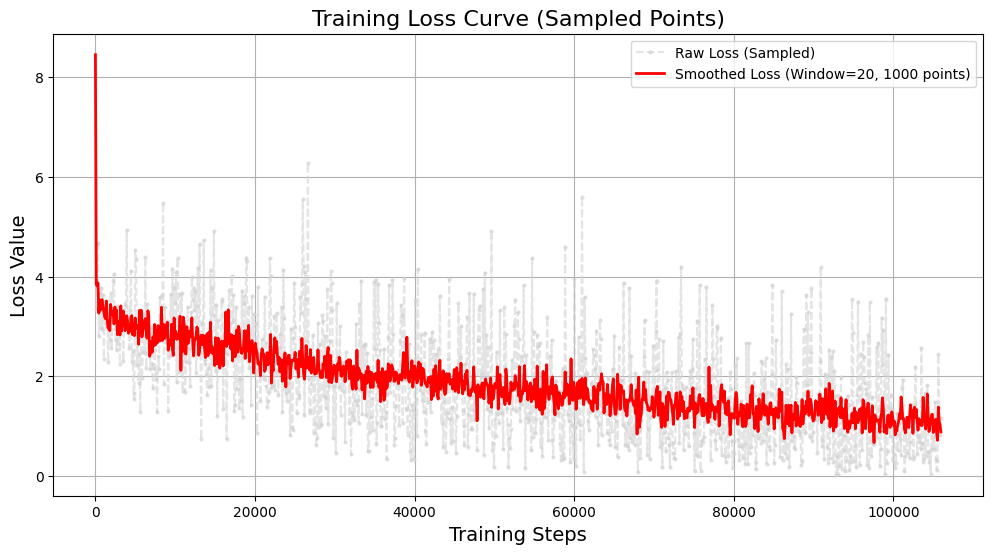

In [67]:
#TASK.3 Bi LSTM+GRU
hidden_size = 256
teacher_forcing_ratio=0.5
epochs = 5
save_checkpoints_path='./checkpoints/task3'
plot_loss_path='./checkpoints/task3'
encoder_fetch_wholeseq=True

#to conotinue from interrupted process 注释以下两行来阻止编码器和解码器初始化
encoder_bilstm = Encoder_BiLSTM(input_lang.n_words, hidden_size).to(device)
decoder_gru = Decoder(hidden_size, output_lang.n_words).to(device)

trainIters(teacher_forcing_ratio=teacher_forcing_ratio, encoder=encoder_bilstm, decoder=decoder_gru,
           epochs=5, print_every=5000, plot_loss_path=plot_loss_path, learning_rate=0.01,save_checkpoints_path=save_checkpoints_path,encoder_fetch_wholeseq=encoder_fetch_wholeseq)

In [20]:
hidden_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = './checkpoints/task3/checkpoint_epoch_4.pth'
encoder_fetch_wholeseq=True

encoder_bilstm = Encoder_BiLSTM(input_lang.n_words, hidden_size).to(device)
decoder_gru = Decoder(hidden_size, output_lang.n_words).to(device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

encoder_bilstm.load_state_dict(checkpoint['encoder_state_dict'])
decoder_gru.load_state_dict(checkpoint['decoder_state_dict'])

evaluateRandomly(encoder_bilstm, decoder_gru, encoder_fetch_wholeseq=encoder_fetch_wholeseq)
input,gt,predict = inference(encoder_bilstm, decoder_gru, test_pairs,encoder_fetch_wholeseq=encoder_fetch_wholeseq)
eval(gt, predict)

> c est un homme grossier .
= he is an ill mannered man .
< he is a man man . <EOS>

> j engage des poursuites .
= i m pressing charges .
< i m going . <EOS>

> je suis ouvert aux suggestions .
= i m wide open for suggestions .
< i m open to open . <EOS>

> tu es pile a l heure .
= you re just in time .
< you re on my way . <EOS>

> je crains d avoir de mauvaises nouvelles .
= i m afraid i have some bad news .
< i m afraid i have some bad bad news . <EOS>

> il reste a cet hotel depuis cinq jours .
= he s been staying at that hotel since five days ago .
< he stayed to he to at the hotel days . <EOS>

> vous etes une femme formidable !
= you re a wonderful woman .
< you re a wonderful woman . <EOS>

> vous tremblez .
= you re shivering .
< you re shivering . <EOS>

> il devrait me remercier .
= he should thank me .
< i must be blind . <EOS>

> je suis maintenant dans une position delicate .
= i m now in a delicate position .
< i m now in a a now now . <EOS>



100%|██████████| 2355/2355 [00:07<00:00, 297.29it/s]


=== Evaluation score - Rouge score ===
Rouge1 fmeasure:	 0.6131307482719421
Rouge1 precision:	 0.5769073367118835
Rouge1 recall:  	 0.6621410846710205
Rouge2 fmeasure:	 0.42858123779296875
Rouge2 precision:	 0.39666253328323364
Rouge2 recall:  	 0.4739260971546173


In [93]:
import torch.nn.functional as F
import torch.nn as nn
class EncoderRNN(nn.Module):
    # 定义编码器类，继承自 nn.Module
    def __init__(self, input_size, hidden_size):
        # 构造函数：input_size 是输入词汇表大小，hidden_size 是隐藏层维度
        super(EncoderRNN, self).__init__()
        # 调用父类构造函数
        self.hidden_size = hidden_size
        # 存储隐藏层大小
        self.embedding = nn.Embedding(input_size, hidden_size)
        # 嵌入层：将输入词元（索引）映射到稠密的 hidden_size 维向量
        self.gru = nn.GRU(hidden_size, hidden_size)
        # GRU层：核心循环单元，输入和输出维度都是 hidden_size
    def forward(self, input, hidden):
        # 前向传播函数：处理单个输入词元
        # input: 当前时间步的输入词元（索引），形状通常为 (1)
        # hidden: 上一时间步的隐藏状态，形状 (1, 1, hidden_size)
        embedded = self.embedding(input).view(1, 1, -1)
        # 1. 嵌入：查找嵌入向量
        # 2. 塑形：将嵌入向量从 (1, hidden_size) [embedding 的输出] 塑形为 GRU 期望的 (seq_len=1, batch_size=1, hidden_size)
        output = embedded
        # 初始 GRU 输入为嵌入向量
        output, hidden = self.gru(output, hidden)
        # 通过 GRU 单元：计算新的输出和新的隐藏状态
        # output: 当前时间步的输出 (通常被忽略)
        # hidden: GRU 的最终隐藏状态 (包含上下文信息)
        return output, hidden #(1,1,H)
        # 返回 GRU 输出和更新后的隐藏状态（上下文向量）
    def initHidden(self):
        # 初始化隐藏状态函数
        return torch.zeros(1, 1, self.hidden_size, device=device)
        # 返回一个全零张量作为初始隐藏状态，形状 (num_layers=1, batch_size=1, hidden_size

class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(AttnDecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.embedding = nn.Embedding(self.output_size, self.hidden_size)

        # 1. Attention Combination Layer (用于将 [h_t ; context_t] 映射为 h_t'，并进行预测)
        # 它接收 2*H 维度，输出 H 维度
        self.attn_combine = nn.Linear(self.hidden_size * 2, self.hidden_size)
        # --- 核心解码器层 ---
        # GRU 仅接收 H 维输入（当前的词嵌入）
        self.gru = nn.GRU(self.hidden_size, self.hidden_size)
        # 2. 最终输出层：从 H 维度 (h_t') 映射到 词汇表大小
        self.out = nn.Linear(self.hidden_size, self.output_size)

    def forward(self, input, hidden, encoder_outputs):
        # input: 当前输入词元 (1)
        # hidden: 前一时间步的隐藏状态 (1, 1, H) -> 也作为 GRU 的初始 hidden
        # encoder_outputs: 所有编码器时间步的输出 (max_length, H)

        embedded = self.embedding(input).view(1, 1, -1) # (1, 1, H)
        # 1. 定义 K, Q, V
        # K (键) & V (值): 编码器的输出序列 (max_length, H)
        K = encoder_outputs
        V = encoder_outputs
        # Q (查询): 解码器上一时间步的隐藏状态，形状 (1, H)
        Q = hidden.squeeze(0)
        # 2. Attention Scores (Dot-Product)
        # Q (1, H) @ K.T (H, max_length) -> attn_scores (1, max_length)
        attn_scores = torch.matmul(Q, K.transpose(0, 1))
        attn_weights = F.softmax(attn_scores, dim=1) # 形状: (1, max_length)
        # 3. Context Vector
        # V (max_length, H) -> V_bmm (1, max_length, H)
        V_bmm = V.unsqueeze(0)
        # context: (1, 1, H)
        context = attn_weights.unsqueeze(0).bmm(V_bmm)
        # GRU 输入: 仅为当前词元的嵌入 (embedded)
        #embedded (1,1,H)
        #直接拼接(1,1,2*H)

        attn_output = torch.cat((embedded, context), dim=2)  #直接拼接(1,1,2*H)
        # (1,1,2H)->(1,1,H)
        attn_output = self.attn_combine(attn_output)
        attn_output = F.tanh(attn_output)

        output, hidden = self.gru(attn_output, hidden)  #(1,1,H)
        #(1,h)->(1,out_put_size)
        output = F.log_softmax(self.out(output[0]), dim=1)
        #print(output.size())

        return output, hidden, attn_weights

Epoch: 0/5
1m 17s (- 26m 0s) (5000 4%) 3.3226
2m 37s (- 25m 13s) (10000 9%) 2.8444
4m 0s (- 24m 19s) (15000 14%) 2.5843
5m 23s (- 23m 9s) (20000 18%) 2.4106
Epoch: 1/5
6m 47s (- 21m 58s) (25000 23%) 2.2252
8m 12s (- 20m 47s) (30000 28%) 2.0781
9m 40s (- 19m 36s) (35000 33%) 1.9821
11m 8s (- 18m 21s) (40000 37%) 1.8846
Epoch: 2/5
12m 36s (- 17m 4s) (45000 42%) 1.7967
14m 1s (- 15m 41s) (50000 47%) 1.6665
15m 31s (- 14m 22s) (55000 51%) 1.6073
17m 2s (- 13m 2s) (60000 56%) 1.5383
Epoch: 3/5
18m 32s (- 11m 40s) (65000 61%) 1.4977
20m 1s (- 10m 16s) (70000 66%) 1.4022
21m 30s (- 8m 52s) (75000 70%) 1.3595
22m 58s (- 7m 27s) (80000 75%) 1.2887
Epoch: 4/5
24m 26s (- 6m 1s) (85000 80%) 1.3020
25m 56s (- 4m 35s) (90000 84%) 1.2187
27m 44s (- 3m 11s) (95000 89%) 1.1805
29m 5s (- 1m 43s) (100000 94%) 1.1331
30m 25s (- 0m 16s) (105000 99%) 1.1426


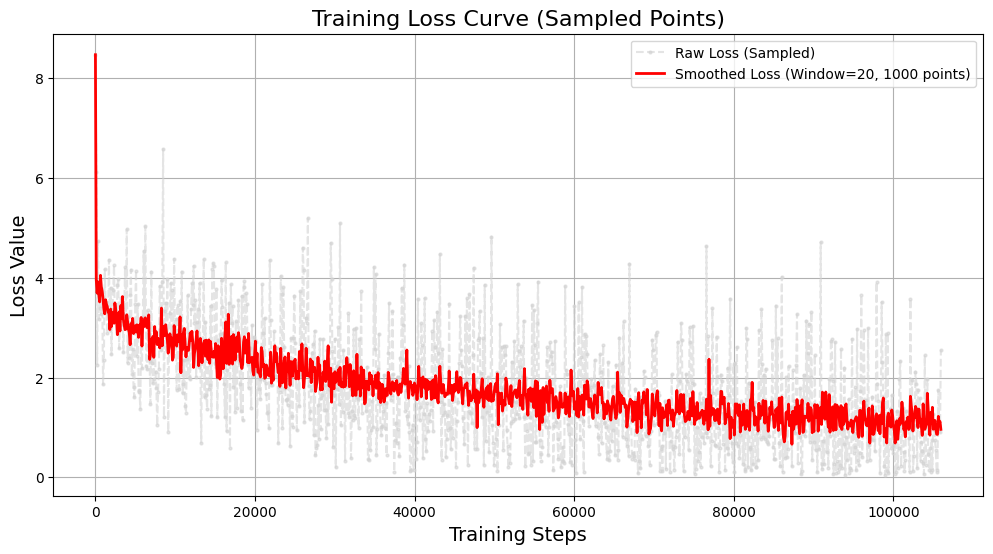

In [94]:
hidden_size = 256
teacher_forcing_ratio=0.5
epochs = 5
save_checkpoints_path='./checkpoints/task4'
plot_loss_path='./checkpoints/task4'

if_attention=True
#to conotinue from interrupted process 注释以下两行来阻止编码器和解码器初始化
encoder_GRU = EncoderRNN(input_lang.n_words, hidden_size).to(device)
dncoder_GRU_att = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)

trainIters(teacher_forcing_ratio=teacher_forcing_ratio, encoder=encoder_GRU, decoder=dncoder_GRU_att,
           epochs=5, print_every=5000, plot_loss_path=plot_loss_path, learning_rate=0.01,save_checkpoints_path=save_checkpoints_path,
           if_attention=if_attention)

In [95]:
hidden_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = './checkpoints/task4/checkpoint_epoch_4.pth'
if_attention=True

encoder_GRU = EncoderRNN(input_lang.n_words, hidden_size).to(device)
dncoder_GRU_att = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

encoder_GRU.load_state_dict(checkpoint['encoder_state_dict'])
dncoder_GRU_att.load_state_dict(checkpoint['decoder_state_dict'])

evaluateRandomly(encoder_GRU, dncoder_GRU_att, if_attention=if_attention)
input,gt,predict = inference(encoder_GRU, dncoder_GRU_att, test_pairs,if_attention=if_attention)
eval(gt, predict)

> desole d avoir ete si grossier tout a l heure .
= i m sorry i was rude before .
< i m sorry i was rude before . <EOS>

> j envisage de rendre visite a mon ami l annee prochaine .
= i m thinking about visiting my friend next year .
< i m planning to go my my . <EOS>

> je suis vraiment embarrasse .
= i m really embarrassed .
< i m really embarrassed . <EOS>

> je suis enchante de vous rencontrer .
= i m glad to see you .
< i m glad to meet you . <EOS>

> tu es un enfant talentueux .
= you re a talented kid .
< you re a talented kid . <EOS>

> ils sont tous deux bons .
= they are both good .
< they re both good . <EOS>

> tu es le bienvenu ici .
= you are welcome here .
< you re welcome here . <EOS>

> il est pitoyable et idiot .
= he s pathetic and stupid .
< he is always and stupid . <EOS>

> il est pauvre .
= he is poor .
< he is poor . <EOS>

> nous sommes tous impressionnes .
= we re all impressed .
< we re all impressed . <EOS>



100%|██████████| 2355/2355 [00:13<00:00, 179.55it/s]


=== Evaluation score - Rouge score ===
Rouge1 fmeasure:	 0.6289764046669006
Rouge1 precision:	 0.5970224738121033
Rouge1 recall:  	 0.6736688017845154
Rouge2 fmeasure:	 0.44719818234443665
Rouge2 precision:	 0.4172162711620331
Rouge2 recall:  	 0.49126386642456055


In [6]:
# 5 transformer encoder
import torch.nn as nn
import torch
import torch.nn.functional as F

# use transformer as an encoder
class TransformerEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, nhead=8, num_layers=1, max_len=512, dropout=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.pos_encoder = nn.Embedding(max_len, hidden_size)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size, # 注意：PyTorch 默认的参数名称是 d_model，不是 hidden_size 但含义就是模型宽度 (hidden dim)
            dim_feedforward=hidden_size * 4,
            nhead=nhead, # 多头attention
            dropout=dropout,
            batch_first=True  #设置为True时 输出为 (Batch Size, Sequence Length, Feature Dimension)
        )

        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


    def forward(self, input_seq):
        # input_seq 形状:
        # 1. 嵌入和位置编码
        input_seq = input_seq.transpose(0, 1)
        #转置为 (batch_size, seq_len)
        seq_len = input_seq.size(1)
        #(1,seq_len)
        pos = torch.arange(seq_len, device=input_seq.device).unsqueeze(0)
        #(batch_size,seq_len,hidden_size)+(1,seq_len,hidden_size)
        # -> (B,S,H) 广播
        embedded = self.embedding(input_seq) + self.pos_encoder(pos)
        embedded = self.dropout(embedded)
        #随机dropout  '
        # 2. 运行 Transformer 编码器
        # encoder_outputs 形状: (batch_size, seq_len, hidden_size)
        # input (B,S,H) ,output (B, S, H)
        encoder_outputs = self.transformer_encoder(embedded)
        # 3. 计算 GRU 解码器的初始隐藏状态 (上下文向量)
        # 对序列长度维度 (dim=1) 取平均: (batch_size, hidden_size)
        # mean of hidden
        context_vector_mean = torch.mean(encoder_outputs, dim=1)
        # 4. 调整上下文向量的形状以匹配原始 GRU hidden (L=1, B=1, H)
        # 假设 batch_size=1 (通常在 Seq2Seq 循环中处理单个句子)
        # hidden_context 形状: (1, 1, hidden_size_mean)
        hidden_context = context_vector_mean.unsqueeze(0)
        # 返回 K, V 序列 (encoder_outputs) 和 初始隐藏状态 (hidden_context)
        # hidden_context (1, 1, H)
        return encoder_outputs, hidden_context

    # transformer 不再有Recurrent 结构，所以并不需要init, 这只是给train函数的占位功能
    def initHidden(self):
        pass


class Decoder(nn.Module):
    # 定义解码器类
    def __init__(self, hidden_size, output_size):
        # 构造函数：hidden_size 是隐藏层维度，output_size 是输出词汇表大小
        super(Decoder, self).__init__()
        # 调用父类构造函数
        self.hidden_size = hidden_size
        # 存储隐藏层大小
        self.embedding = nn.Embedding(output_size, hidden_size)
        # 嵌入层：将目标词元（索引）映射到 hidden_size 维向量
        self.gru = nn.GRU(hidden_size, hidden_size)
        # GRU层：核心循环单元，输入和输出维度都是 hidden_size
        self.out = nn.Linear(hidden_size, output_size)
        # 线性层：将 GRU 的隐藏状态映射到输出词汇表的维度
        self.softmax = nn.LogSoftmax(dim=1)
        # LogSoftmax：将线性层的输出转换为对数概率（Log-probabilities），通常用于计算损失。

    def forward(self, input, hidden):
        # 前向传播函数：解码器的一个时间步
        # input: 当前时间步的输入词元（通常是上一步的预测结果或教师强制的真实标签）
        # hidden: 当前时间步的隐藏状态（初始时为编码器的上下文向量）
        output = self.embedding(input).view(1, 1, -1)
        # 1. 嵌入：查找输入词元的嵌入向量
        # 2. 塑形：从 (1, hidden_size) 塑形为 (seq_len=1, batch_size=1, hidden_size)
        output = F.relu(output)
        # 应用 ReLU 激活函数（在 GRU 之前使用是可选的设计）
        output, hidden = self.gru(output, hidden)
        # 通过 GRU 单元：处理当前输入词元和隐藏状态，得到新的输出和隐藏状态
        # --- 下面是关键的输出处理部分 ---
        output_for_linear = output.squeeze(0) # 修正或优化点：从 (1, 1, H) 变为 (1, H)
        # 为了清晰和健壮，推荐使用 .squeeze(0) 来移除序列长度为 1 的维度。
        output = self.softmax(self.out(output_for_linear))
        # 1. self.out(...)：将 (1, hidden_size) 映射到 (1, output_size)
        # 2. self.softmax(...)：应用 LogSoftmax，得到预测词元的对数概率
        return output, hidden
        # 返回预测的词元概率对数和更新后的隐藏状态

    def initHidden(self):
        # 初始化隐藏状态函数
        return torch.zeros(1, 1, self.hidden_size, device=device)
        # 返回一个全零张量作为初始隐藏状态（通常在 Seq2Seq 中不使用，而是接收编码器的输出）

Epoch: 0/5
0m 42s (- 14m 22s) (5000 4%) 3.2145
1m 21s (- 13m 5s) (10000 9%) 2.8192
2m 0s (- 12m 7s) (15000 14%) 2.6481
2m 42s (- 11m 37s) (20000 18%) 2.5202
Epoch: 1/5
3m 32s (- 11m 26s) (25000 23%) 2.3851
4m 16s (- 10m 48s) (30000 28%) 2.2643
5m 1s (- 10m 10s) (35000 33%) 2.1953
6m 2s (- 9m 57s) (40000 37%) 2.1336
Epoch: 2/5
7m 27s (- 10m 5s) (45000 42%) 2.0735
8m 37s (- 9m 39s) (50000 47%) 1.9754
9m 35s (- 8m 53s) (55000 51%) 1.9370
10m 50s (- 8m 18s) (60000 56%) 1.8844
Epoch: 3/5
12m 2s (- 7m 34s) (65000 61%) 1.8539
13m 26s (- 6m 54s) (70000 66%) 1.7633
14m 49s (- 6m 6s) (75000 70%) 1.7321
16m 15s (- 5m 16s) (80000 75%) 1.7106
Epoch: 4/5
17m 14s (- 4m 14s) (85000 80%) 1.7036
18m 37s (- 3m 17s) (90000 84%) 1.6087
20m 0s (- 2m 18s) (95000 89%) 1.5779
21m 24s (- 1m 16s) (100000 94%) 1.5650
22m 45s (- 0m 12s) (105000 99%) 1.5623


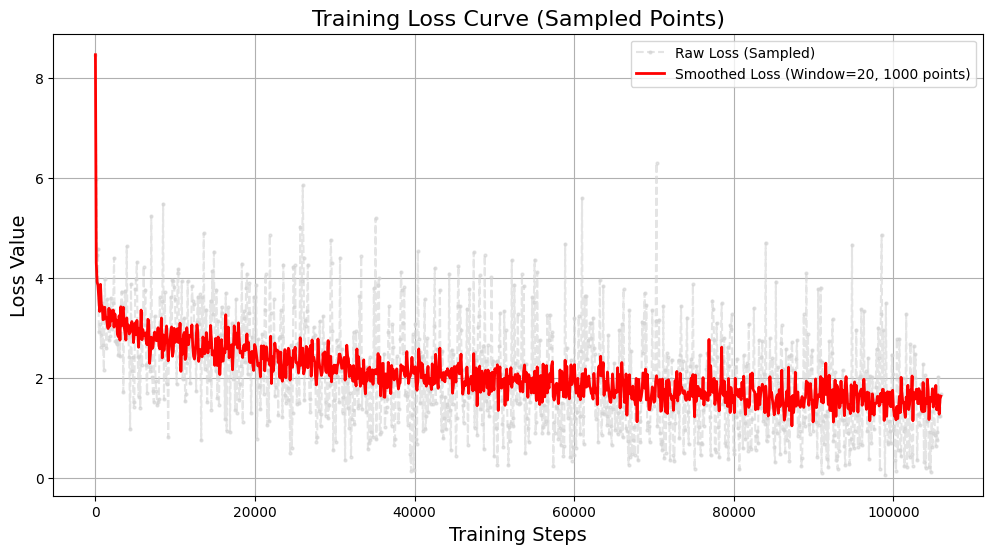

In [11]:
hidden_size = 256
teacher_forcing_ratio=0.5
epochs = 5
nhead=8
num_layers=1
save_checkpoints_path='./checkpoints/task_test'
plot_loss_path='./checkpoints/task_test'

encoder_fetch_wholeseq=True
#to conotinue from interrupted process 注释以下两行来阻止编码器和解码器初始化
encoder_transformer = TransformerEncoder(input_lang.n_words, hidden_size,nhead=nhead,num_layers=num_layers).to(device)
dncoder_GRU = Decoder(hidden_size, output_lang.n_words).to(device)

trainIters(teacher_forcing_ratio=teacher_forcing_ratio, encoder=encoder_transformer, decoder=dncoder_GRU,
           epochs=5, print_every=5000, plot_loss_path=plot_loss_path, learning_rate=0.005,save_checkpoints_path=save_checkpoints_path,encoder_fetch_wholeseq=encoder_fetch_wholeseq)

In [21]:
hidden_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = './checkpoints/task5/checkpoint_epoch_4.pth'
encoder_fetch_wholeseq = True

encoder_transformer = TransformerEncoder(input_lang.n_words, hidden_size).to(device)
dncoder_GRU = Decoder(hidden_size, output_lang.n_words).to(device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

encoder_transformer.load_state_dict(checkpoint['encoder_state_dict'])
dncoder_GRU.load_state_dict(checkpoint['decoder_state_dict'])

evaluateRandomly(encoder_transformer, dncoder_GRU, encoder_fetch_wholeseq=encoder_fetch_wholeseq)
input, gt, predict = inference(encoder_transformer, dncoder_GRU, test_pairs, encoder_fetch_wholeseq=encoder_fetch_wholeseq)
eval(gt, predict)

> je suis content que tu ailles a nouveau bien .
= i m glad you re ok again .
< i m glad you re ok good . <EOS>

> je ne vais pas le dire deux fois .
= i m not going to say it twice .
< i m not going to make up for . . <EOS>

> j ai peur des loups .
= i m afraid of wolves .
< i m afraid of dogs . <EOS>

> je ne suis pas de garde demain .
= i am off duty tomorrow .
< i m not duty tomorrow . <EOS>

> il est beaucoup plus grand que moi .
= he is much taller than i am .
< he s much taller than i am . <EOS>

> elle a peur de retomber malade .
= she is afraid of falling ill again .
< she is afraid of death . <EOS>

> j envisage d aller a l etranger l an prochain .
= i m thinking of going abroad next year .
< i m thinking to go to eat abroad . <EOS>

> il est impatient de te voir .
= he is impatient to see you .
< he is eager to see you <EOS>

> je suis en train de ramener une pizza a la maison .
= i m bringing home a pizza .
< i m taking a couple of days . <EOS>

> je suis sincerement desole

100%|██████████| 2355/2355 [00:08<00:00, 281.94it/s]


=== Evaluation score - Rouge score ===
Rouge1 fmeasure:	 0.5663669109344482
Rouge1 precision:	 0.538169264793396
Rouge1 recall:  	 0.6084070801734924
Rouge2 fmeasure:	 0.37893855571746826
Rouge2 precision:	 0.3545594811439514
Rouge2 recall:  	 0.41708463430404663


Epoch: 0/5
1m 2s (- 21m 0s) (5000 4%) 3.3246
2m 7s (- 20m 26s) (10000 9%) 2.9134
3m 14s (- 19m 38s) (15000 14%) 2.7296
4m 21s (- 18m 43s) (20000 18%) 2.5758
Epoch: 1/5
5m 31s (- 17m 52s) (25000 23%) 2.4360
6m 36s (- 16m 44s) (30000 28%) 2.3010
7m 50s (- 15m 53s) (35000 33%) 2.2507
9m 4s (- 14m 57s) (40000 37%) 2.1739
Epoch: 2/5
10m 27s (- 14m 9s) (45000 42%) 2.1085
11m 43s (- 13m 6s) (50000 47%) 2.0035
12m 55s (- 11m 57s) (55000 51%) 1.9715
14m 6s (- 10m 48s) (60000 56%) 1.9074
Epoch: 3/5
15m 23s (- 9m 41s) (65000 61%) 1.8942
16m 40s (- 8m 33s) (70000 66%) 1.7957
17m 57s (- 7m 24s) (75000 70%) 1.7530
19m 15s (- 6m 14s) (80000 75%) 1.7060
Epoch: 4/5
20m 27s (- 5m 2s) (85000 80%) 1.7130
21m 35s (- 3m 49s) (90000 84%) 1.6274
22m 40s (- 2m 36s) (95000 89%) 1.5796
23m 47s (- 1m 24s) (100000 94%) 1.5586
24m 56s (- 0m 13s) (105000 99%) 1.5534
Epoch: 0/5
1m 26s (- 29m 12s) (5000 4%) 3.2845
2m 55s (- 27m 59s) (10000 9%) 2.9115
4m 23s (- 26m 38s) (15000 14%) 2.7361
5m 53s (- 25m 17s) (20000 18%)

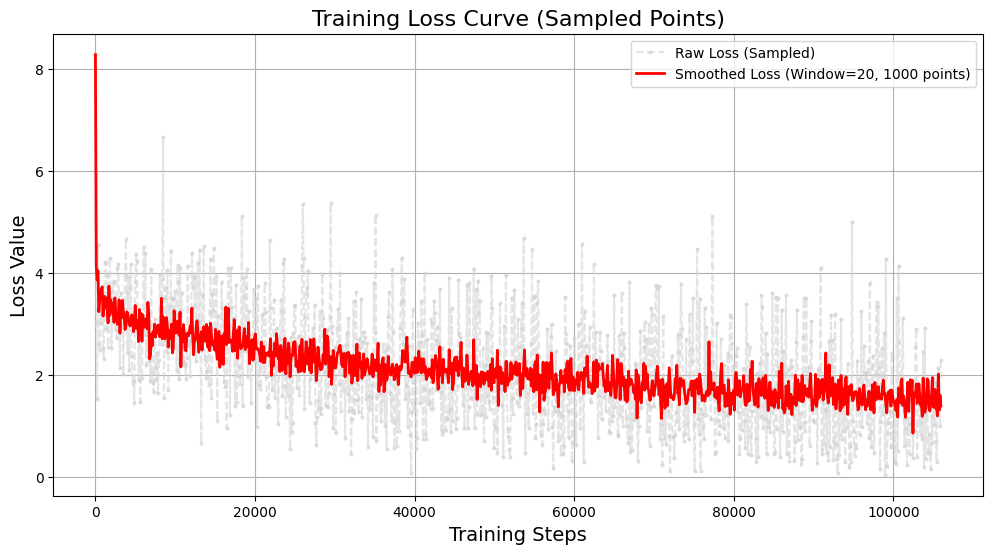

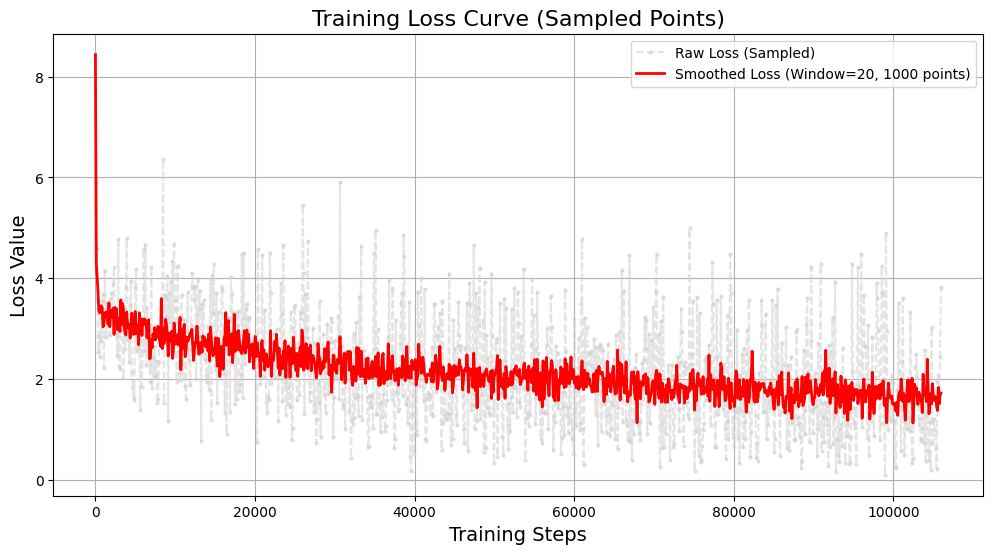

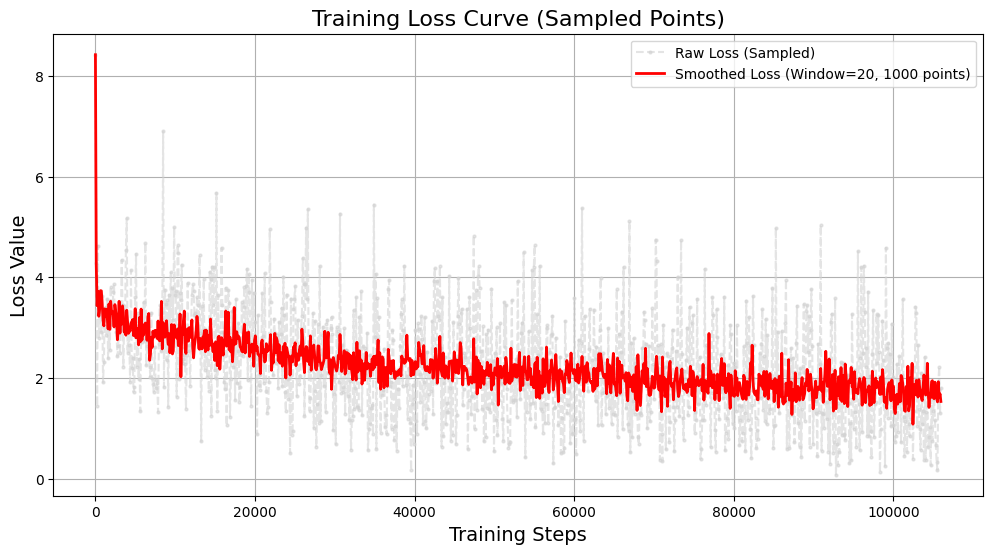

In [11]:
from pathlib import Path
hidden_size = 256
teacher_forcing_ratio=0.5
epochs = 5
nhead=[16]
num_layers=[1,3,5]

for head in nhead:
    for num_layer in num_layers:

        save_checkpoints_path='./checkpoints/head_'+str(head)+'_num_layer'+str(num_layer)
        plot_loss_path='./checkpoints/head_'+str(head)+'_num_layer'+str(num_layer)

        Path(save_checkpoints_path).mkdir(parents=True, exist_ok=True)
        Path(plot_loss_path).mkdir(parents=True, exist_ok=True)

        encoder_fetch_wholeseq=True
        #to conotinue from interrupted process 注释以下两行来阻止编码器和解码器初始化
        encoder_transformer = TransformerEncoder(input_lang.n_words, hidden_size,nhead=head,num_layers=num_layer).to(device)
        dncoder_GRU = Decoder(hidden_size, output_lang.n_words).to(device)

        trainIters(teacher_forcing_ratio=teacher_forcing_ratio, encoder=encoder_transformer, decoder=dncoder_GRU,
           epochs=epochs, print_every=5000, plot_loss_path=plot_loss_path, learning_rate=0.005,save_checkpoints_path=save_checkpoints_path,encoder_fetch_wholeseq=encoder_fetch_wholeseq)



In [20]:
hidden_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH_list = ['./checkpoints/head_4_num_layer1/checkpoint_epoch_4.pth',
                   './checkpoints/head_4_num_layer3/checkpoint_epoch_4.pth',
                   './checkpoints/head_4_num_layer5/checkpoint_epoch_4.pth',
                   './checkpoints/head_8_num_layer1/checkpoint_epoch_4.pth',
                   './checkpoints/head_8_num_layer3/checkpoint_epoch_4.pth',
                   './checkpoints/head_8_num_layer5/checkpoint_epoch_4.pth',
                   './checkpoints/head_16_num_layer1/checkpoint_epoch_4.pth',
                   './checkpoints/head_16_num_layer3/checkpoint_epoch_4.pth',
                   './checkpoints/head_16_num_layer5/checkpoint_epoch_4.pth',]
encoder_fetch_wholeseq = True

for CHECKPOINT_PATH in CHECKPOINT_PATH_list:
    if 'head_4' in CHECKPOINT_PATH:
        head=4
    if 'head_8' in CHECKPOINT_PATH:
        head=8
    if 'head_16' in CHECKPOINT_PATH:
        head=16
    if 'layer1' in CHECKPOINT_PATH:
        num_layers=1
    if 'layer3' in CHECKPOINT_PATH:
        num_layers=3
    if 'layer5' in CHECKPOINT_PATH:
        num_layers=5
    print(head)
    print(num_layers)
    encoder_transformer = TransformerEncoder(input_lang.n_words, hidden_size,nhead=head,num_layers=num_layers).to(device)
    dncoder_GRU = Decoder(hidden_size, output_lang.n_words).to(device)

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

    encoder_transformer.load_state_dict(checkpoint['encoder_state_dict'])
    dncoder_GRU.load_state_dict(checkpoint['decoder_state_dict'])

    input, gt, predict = inference(encoder_transformer, dncoder_GRU, test_pairs, encoder_fetch_wholeseq=encoder_fetch_wholeseq)
    print(CHECKPOINT_PATH)
    eval(gt, predict)


4
1


100%|██████████| 2355/2355 [00:07<00:00, 317.52it/s]


./checkpoints/head_4_num_layer1/checkpoint_epoch_4.pth
=== Evaluation score - Rouge score ===
Rouge1 fmeasure:	 0.5556648969650269
Rouge1 precision:	 0.5338804125785828
Rouge1 recall:  	 0.5895854830741882
Rouge2 fmeasure:	 0.366313636302948
Rouge2 precision:	 0.346648633480072
Rouge2 recall:  	 0.39832109212875366
4
3


100%|██████████| 2355/2355 [00:08<00:00, 282.26it/s]


./checkpoints/head_4_num_layer3/checkpoint_epoch_4.pth
=== Evaluation score - Rouge score ===
Rouge1 fmeasure:	 0.5511298179626465
Rouge1 precision:	 0.5370875000953674
Rouge1 recall:  	 0.5776011347770691
Rouge2 fmeasure:	 0.3633241057395935
Rouge2 precision:	 0.34942182898521423
Rouge2 recall:  	 0.38969704508781433
4
5


...

./checkpoints/head_16_num_layer1/checkpoint_epoch_4.pth
=== Evaluation score - Rouge score ===
Rouge1 fmeasure:	 0.5680106282234192
Rouge1 precision:	 0.5352178812026978
Rouge1 recall:  	 0.6146911978721619
Rouge2 fmeasure:	 0.38111159205436707
Rouge2 precision:	 0.3531428277492523
Rouge2 recall:  	 0.4228461980819702
16
3


100%|██████████| 2355/2355 [00:19<00:00, 123.44it/s]


./checkpoints/head_16_num_layer3/checkpoint_epoch_4.pth
=== Evaluation score - Rouge score ===
Rouge1 fmeasure:	 0.5492538809776306
Rouge1 precision:	 0.5302067995071411
Rouge1 recall:  	 0.5804794430732727
Rouge2 fmeasure:	 0.3592059016227722
Rouge2 precision:	 0.341368168592453
Rouge2 recall:  	 0.38901087641716003
16
5


100%|██████████| 2355/2355 [00:19<00:00, 118.03it/s]


./checkpoints/head_16_num_layer5/checkpoint_epoch_4.pth
=== Evaluation score - Rouge score ===
Rouge1 fmeasure:	 0.5420989394187927
Rouge1 precision:	 0.5231744647026062
Rouge1 recall:  	 0.5723685026168823
Rouge2 fmeasure:	 0.35574617981910706
Rouge2 precision:	 0.33786964416503906
Rouge2 recall:  	 0.3848123252391815
